In [1]:
!pip install ultralytics
from ultralytics import YOLO
import cv2
import pandas as pd
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import cv2
import json
import matplotlib.patches as patches
from scipy.spatial import distance
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

In [2]:
model_person = YOLO("yolov8n.pt")
image_data = Image.open('L_nXP3v_DA8_250.png')
results = model_person.predict(image_data,classes=[0],conf=0.2,show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 384x640 11 persons, 267.9ms
Speed: 2.8ms preprocess, 267.9ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)


In [3]:
[list(image_data.size)[0]//2,list(image_data.size)[1]//2]

[640, 360]

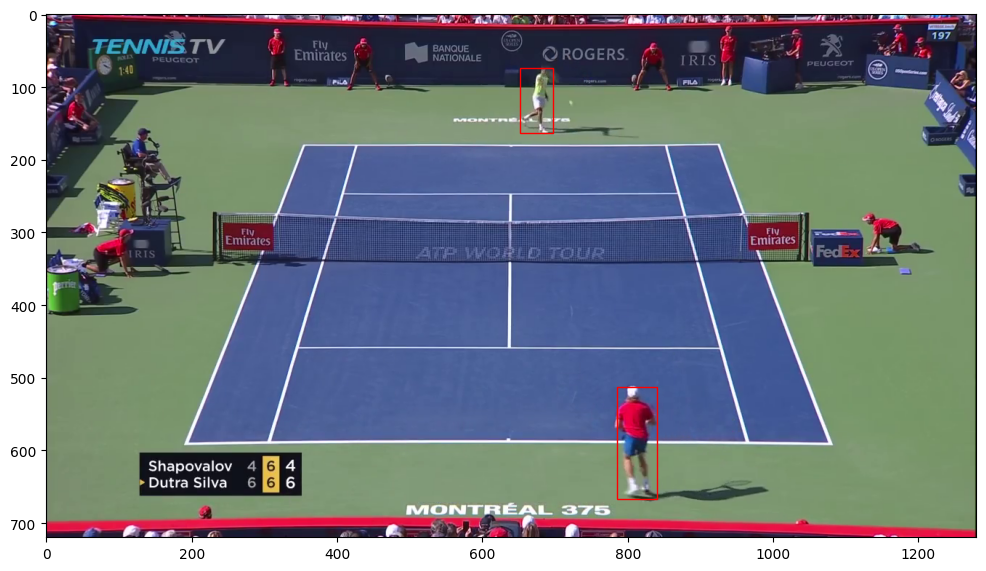

In [4]:
fig, ax = plt.subplots(1, figsize=(12, 8))
image_plot = ax.imshow(image_data)
boxes = []
distance_centre = pd.DataFrame(columns=['distance'])
image_centre = [list(image_data.size)[0]//2,list(image_data.size)[1]//2]
for result in results:
  for number,box in enumerate(result.boxes.xyxy.tolist()):
    distance_centre.loc[number,'distance'] = distance.euclidean(image_centre,np.array(box[:2]))
for result in results:
    for number,box in enumerate(result.boxes.xywh.tolist()):
      if number in distance_centre.sort_values(by='distance',ascending=True)[:2].index:
        ax.add_patch(patches.Rectangle((box[0] - box[2]/2, box[1] - box[3]/2), box[2], box[3], linewidth=1, edgecolor='r', facecolor='none'))
        boxes.append(box)
plt.show()

In [5]:
player_image_1 = image_data.crop((boxes[0][0]-boxes[0][2]/2,boxes[0][1]-boxes[0][3]/2,boxes[0][0]+boxes[0][2]/2,boxes[0][1]+boxes[0][3]/2))
player_image_2 = image_data.crop((boxes[1][0]-boxes[1][2]/2,boxes[1][1]-boxes[1][3]/2,boxes[1][0]+boxes[1][2]/2,boxes[1][1]+boxes[1][3]/2))

In [6]:
kmeans = KMeans(n_clusters=10)
kmeans.fit(np.array(player_image_1).reshape((-1, 3)))
colors_1 = kmeans.cluster_centers_
kmeans.fit(np.array(player_image_2).reshape((-1, 3)))
colors_2 = kmeans.cluster_centers_

In [7]:
distance.euclidean(colors_1.flatten(),colors_2.flatten())

566.3548261352958

In [8]:
#second iteration

In [ ]:
image_data = Image.open('L_nXP3v_DA8_300.png')
results = model_person.predict(image_data,classes=[0],conf=0.2,show=True)

In [ ]:
[list(image_data.size)[0]//2,list(image_data.size)[1]//2]

In [ ]:
fig, ax = plt.subplots(1, figsize=(12, 8))
image_plot = ax.imshow(image_data)
boxes = []
distance_centre = pd.DataFrame(columns=['distance'])
image_centre = [list(image_data.size)[0]//2,list(image_data.size)[1]//2]
for result in results:
  for number,box in enumerate(result.boxes.xyxy.tolist()):
    distance_centre.loc[number,'distance'] = distance.euclidean(image_centre,np.array(box[:2]))
for result in results:
    for number,box in enumerate(result.boxes.xywh.tolist()):
      if number in distance_centre.sort_values(by='distance',ascending=True)[:2].index:
        ax.add_patch(patches.Rectangle((box[0] - box[2]/2, box[1] - box[3]/2), box[2], box[3], linewidth=1, edgecolor='r', facecolor='none'))
        boxes.append(box)
plt.show()

In [ ]:
player_image_3 = image_data.crop((boxes[0][0]-boxes[0][2]/2,boxes[0][1]-boxes[0][3]/2,boxes[0][0]+boxes[0][2]/2,boxes[0][1]+boxes[0][3]/2))
player_image_4 = image_data.crop((boxes[1][0]-boxes[1][2]/2,boxes[1][1]-boxes[1][3]/2,boxes[1][0]+boxes[1][2]/2,boxes[1][1]+boxes[1][3]/2))

In [ ]:
kmeans = KMeans(n_clusters=10)
kmeans.fit(np.array(player_image_3).reshape((-1, 3)))
colors_3 = kmeans.cluster_centers_
kmeans.fit(np.array(player_image_4).reshape((-1, 3)))
colors_4 = kmeans.cluster_centers_

In [ ]:
distance.euclidean(colors_1.flatten(),colors_3.flatten())